In [2284]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV,StratifiedKFold
from catboost import CatBoostClassifier
from imblearn.over_sampling import ADASYN
from imblearn.pipeline import Pipeline as imbPipeline
from feature_engine import encoding as ce
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.under_sampling import (RandomUnderSampler, 
                                     ClusterCentroids,
                                     TomekLinks,
                                     NeighbourhoodCleaningRule,
                                     NearMiss)
from sklearn.preprocessing import PolynomialFeatures
from scipy.stats import randint,uniform

In [2285]:
df=pd.read_csv('train_apps.csv',sep=',')
df.head()

,front_id,decision_day,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,corp_credit_products,sum_deb_ul_90,sum_deb_ul_30,...,overdraft_app_term_max_360,days_from_authperson_registration,fl_hdb_bki_total_active_products,corp_list,count_all_corp_dashboard_events,p75_time_spent_minutes,sum_deb_investment_90,db_group_last,fl_adminarea,target_value
0,127345,2024-02-01,1.339991,-1.847954,-1.586546,1.774424,-0.400695,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lombard,NaN,0
1,127209,2024-02-01,-2.808489,-3.155914,-2.618329,1.774424,-0.400695,0.842771,NaN,NaN,...,NaN,NaN,NaN,-0.862289,-3.400318,-0.780786,NaN,inn_scoring,NaN,0
2,272776,2024-02-01,2.185431,3.167063,2.369547,-0.709770,-0.400695,0.000000,0.834373,4.897257,...,NaN,NaN,NaN,1.168810,3.015012,0.554064,NaN,NaN,NaN,0
3,127210,2024-02-01,-1.468500,-2.595950,-2.176602,1.774424,-0.400695,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,164500,2024-02-01,0.845440,4.559196,3.467730,-2.484194,-0.400695,0.000000,-0.518122,-3.435251,...,NaN,1.067447,NaN,1.022327,1.506380,0.190096,NaN,NaN,NaN,0


In [2286]:
df.shape

(145241, 28)

<Axes: xlabel='sum_deb_investment_90', ylabel='Count'>

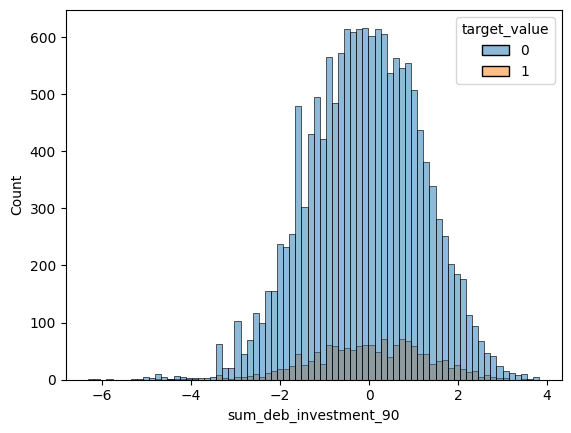

In [2287]:
sns.histplot(data=df,x='sum_deb_investment_90',hue='target_value')

<Axes: xlabel='db_group_last', ylabel='Count'>

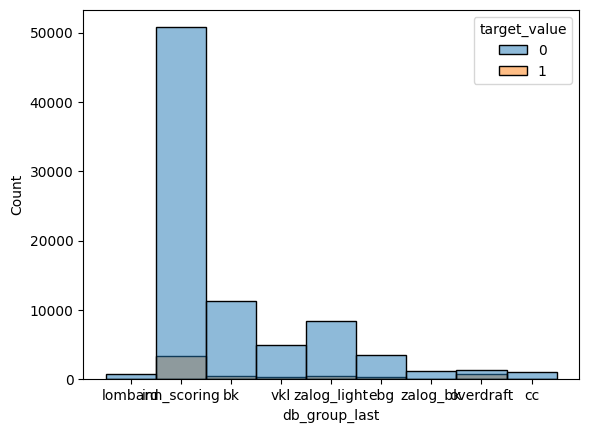

In [2288]:
sns.histplot(data=df,x='db_group_last',hue='target_value')

In [2289]:
df['sum_deb_investment_90'].describe()

c:\Users\zhcri\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\displayhook.py:292: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


count    16544.000000
mean        -0.094382
std          1.270767
min         -6.316172
25%         -0.948789
50%         -0.065987
75%          0.817189
max          3.823178
Name: sum_deb_investment_90, dtype: float64

<Axes: xlabel='count_all_corp_dashboard_events', ylabel='Count'>

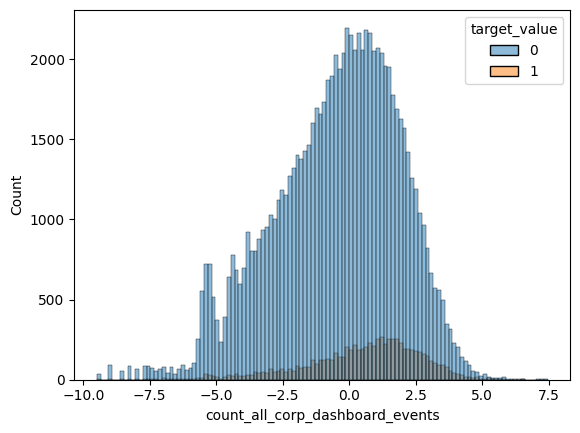

In [2290]:
sns.histplot(data=df,x='count_all_corp_dashboard_events',hue='target_value')

In [2291]:
df.isnull().sum()

front_id                                  0
decision_day                              0
loan_amount_last                          0
overdraft_limit_min                       0
overdraft_limit_max                       0
offered_rate                              0
cb_rate                                   0
corp_credit_products                  51188
sum_deb_ul_90                         54111
sum_deb_ul_30                         61453
cnt_deb_loan_90                       31458
cnt_deb_ul_ip_90                      30305
cnt_deb_ul_ip_30                      33373
balance_rur_amt_30_min                34826
cnt_cred_loan_90                      31458
loan_rev_max_start_non_fin           132635
loan_rev_min_start_fin               124706
app_term_mean_360                     55883
overdraft_app_term_max_360           139732
days_from_authperson_registration     78473
fl_hdb_bki_total_active_products      24368
corp_list                             51188
count_all_corp_dashboard_events 

count    110415.000000
mean         -0.355605
std           3.284146
min          -5.561599
25%          -2.550149
50%           0.001776
75%           2.120235
max           8.483646
Name: balance_rur_amt_30_min, dtype: float64

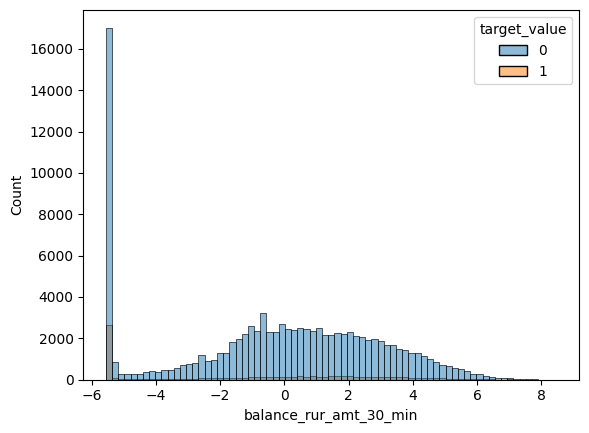

In [2292]:
sns.histplot(data=df,x='balance_rur_amt_30_min',hue='target_value')
df['balance_rur_amt_30_min'].describe()

<Axes: xlabel='db_group_last', ylabel='overdraft_app_term_max_360'>

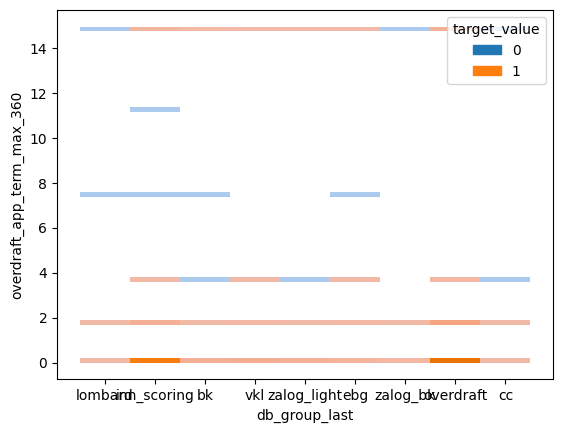

In [2293]:
sns.histplot(data=df,x='db_group_last',y='overdraft_app_term_max_360',hue='target_value')


In [2294]:
df_overdraft = df.loc[df['db_group_last'] == 'overdraft',['overdraft_app_term_max_360']]
df_overdraft.describe()
df_overdraft.value_counts()

overdraft_app_term_max_360
0.000000                      1274
1.869090                       466
14.952721                      328
3.738180                        44
Name: count, dtype: int64

In [2295]:
df['balance_rur_amt_30_min'].describe()

count    110415.000000
mean         -0.355605
std           3.284146
min          -5.561599
25%          -2.550149
50%           0.001776
75%           2.120235
max           8.483646
Name: balance_rur_amt_30_min, dtype: float64

In [2296]:
df['balance_rur_amt_30_min_flag']=df['balance_rur_amt_30_min'].isna().astype(int)
df['balance_rur_amt_30_min']=df['balance_rur_amt_30_min'].fillna(0)
df

,front_id,decision_day,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,corp_credit_products,sum_deb_ul_90,sum_deb_ul_30,...,days_from_authperson_registration,fl_hdb_bki_total_active_products,corp_list,count_all_corp_dashboard_events,p75_time_spent_minutes,sum_deb_investment_90,db_group_last,fl_adminarea,target_value,balance_rur_amt_30_min_flag
0,127345,2024-02-01,1.339991,-1.847954,-1.586546,1.774424,-0.400695,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,lombard,NaN,0,0
1,127209,2024-02-01,-2.808489,-3.155914,-2.618329,1.774424,-0.400695,0.842771,NaN,NaN,...,NaN,NaN,-0.862289,-3.400318,-0.780786,NaN,inn_scoring,NaN,0,0
2,272776,2024-02-01,2.185431,3.167063,2.369547,-0.709770,-0.400695,0.000000,0.834373,4.897257,...,NaN,NaN,1.168810,3.015012,0.554064,NaN,NaN,NaN,0,0
3,127210,2024-02-01,-1.468500,-2.595950,-2.176602,1.774424,-0.400695,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
4,164500,2024-02-01,0.845440,4.559196,3.467730,-2.484194,-0.400695,0.000000,-0.518122,-3.435251,...,1.067447,NaN,1.022327,1.506380,0.190096,NaN,NaN,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145236,258918,2025-06-05,1.339991,2.480726,1.828130,3.903733,1.602779,0.000000,0.893285,5.247350,...,2.592372,1.302069,2.628996,1.589065,0.706500,NaN,zalog_light,Новосибирская область,0,0
145237,176413,2025-06-05,0.845440,3.639458,3.605443,1.596982,1.602779,1.229059,0.576790,2.776671,...,-0.384331,-4.700790,1.214168,0.665258,0.306940,NaN,inn_scoring,г. Москва,0,0
145238,258920,2025-06-05,1.690880,3.960429,2.995393,3.903733,1.602779,1.234158,0.691625,4.440577,...,1.834869,-1.351879,1.806117,2.272156,0.647315,NaN,inn_scoring,г. Санкт - Петербург,0,0
145239,174837,2025-06-05,0.845440,-2.742346,-2.292086,2.661636,1.602779,1.541025,0.109289,0.918909,...,-1.594352,1.674455,1.050198,-0.305594,0.394573,-0.105689,inn_scoring,Красноярский край,0,0


In [2297]:
df['decision_day'].head(20)

0     2024-02-01
1     2024-02-01
2     2024-02-01
3     2024-02-01
4     2024-02-01
5     2024-02-01
6     2024-02-01
7     2024-02-01
8     2024-02-01
9     2024-02-01
10    2024-02-01
11    2024-02-01
12    2024-02-01
13    2024-02-01
14    2024-02-01
15    2024-02-01
16    2024-02-01
17    2024-02-01
18    2024-02-01
19    2024-02-01
Name: decision_day, dtype: object

In [2298]:
df['decision_day'] = pd.to_datetime(df['decision_day'],errors='coerce')

In [2299]:
df['decision_day_flag'] = (df['decision_day'].dt.day >= 25).astype(int)
df['decision_weekend'] = (df['decision_day'].dt.dayofweek >= 5).astype(int)

In [2300]:
df['decision_weekend'].value_counts()

decision_weekend
0    142018
1      3223
Name: count, dtype: int64

In [2301]:
df['decision_day_flag'].value_counts()

decision_day_flag
0    113770
1     31471
Name: count, dtype: int64

In [2302]:
df['decision_day'].unique()

<DatetimeArray>
['2024-02-01 00:00:00', '2024-02-02 00:00:00', '2024-02-03 00:00:00',
 '2024-02-04 00:00:00', '2024-02-05 00:00:00', '2024-02-06 00:00:00',
 '2024-02-07 00:00:00', '2024-02-08 00:00:00', '2024-02-09 00:00:00',
 '2024-02-10 00:00:00',
 ...
 '2025-05-27 00:00:00', '2025-05-28 00:00:00', '2025-05-29 00:00:00',
 '2025-05-30 00:00:00', '2025-05-31 00:00:00', '2025-06-01 00:00:00',
 '2025-06-02 00:00:00', '2025-06-03 00:00:00', '2025-06-04 00:00:00',
 '2025-06-05 00:00:00']
Length: 485, dtype: datetime64[ns]

In [2303]:
df['count_all_corp_dashboard_events'] = df['count_all_corp_dashboard_events'].fillna(0)

In [2304]:
df['rate_spread'] = df['offered_rate'] - df['cb_rate']
df['rate_ratio'] = df['offered_rate'] / df['cb_rate']

<Axes: xlabel='rate_ratio', ylabel='Count'>

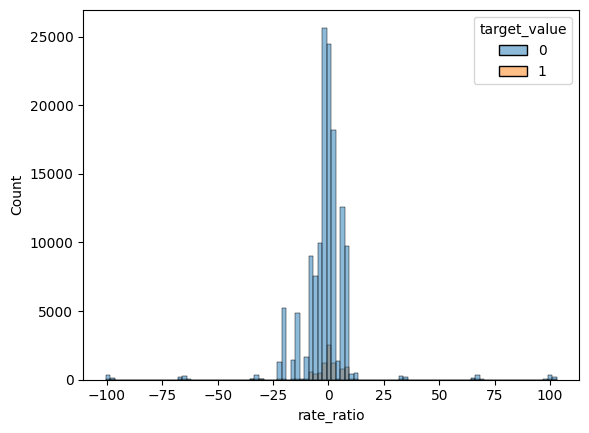

In [2305]:
sns.histplot(data=df, x='rate_ratio', hue='target_value', bins=100)

np.int64(0)

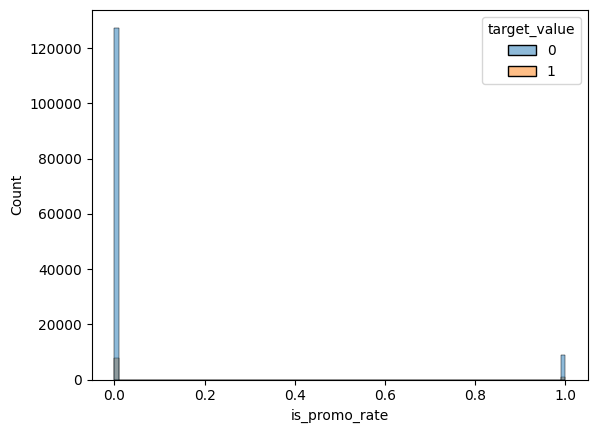

In [2306]:
df['is_promo_rate'] = (df['rate_spread'] < df['rate_spread'].quantile(0.1)).astype(int)
sns.histplot(data=df, x='is_promo_rate', hue='target_value', bins=100)
df['is_promo_rate'].isnull().sum()

<Axes: xlabel='loan_to_od_max', ylabel='Count'>

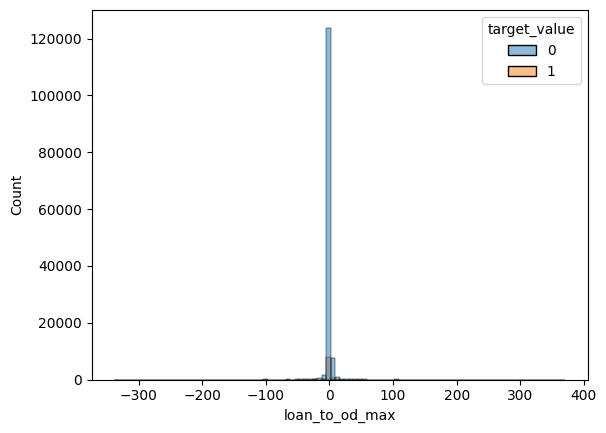

In [2307]:
df['loan_to_od_max'] = df['loan_amount_last'] / df['overdraft_limit_max']
sns.histplot(data=df, x='loan_to_od_max', hue='target_value', bins=100)

In [2308]:
df['loan_to_od_max'].isnull().sum()
df['loan_to_od_max']

0        -0.844596
1         1.072626
2         0.922299
3         0.674676
4         0.243802
            ...   
145236    0.732984
145237    0.234490
145238    0.564494
145239   -0.368852
145240    0.256172
Name: loan_to_od_max, Length: 145241, dtype: float64

<Axes: xlabel='od_range', ylabel='Count'>

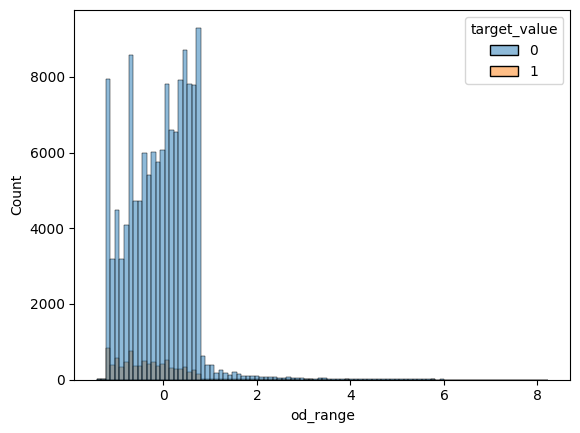

In [2309]:
df['od_range'] = df['overdraft_limit_max'] - df['overdraft_limit_min']
sns.histplot(data=df, x='od_range', hue='target_value', bins=100)
# df['log_od_range'] = np.log1p(df['od_range'].clip(lower=0))
# sns.histplot(data=df, x='log_od_range', hue='target_value', bins=100)

<Axes: xlabel='weighted_spread', ylabel='Count'>

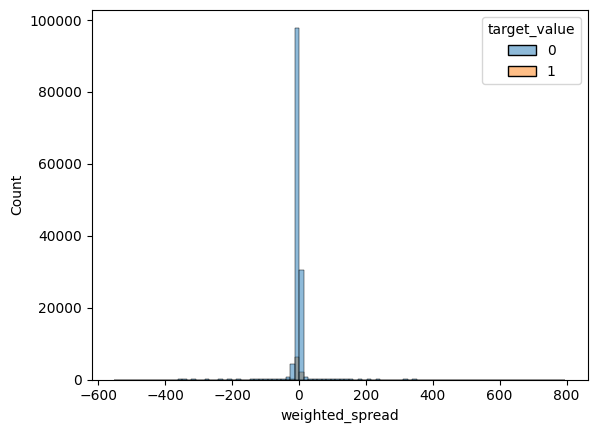

In [2310]:
df['weighted_spread'] = df['rate_spread'] * df['loan_amount_last']
sns.histplot(data=df, x='weighted_spread', hue='target_value', bins=100)

In [2311]:
df['heavy_user'] = (df['p75_time_spent_minutes'] > df['p75_time_spent_minutes'].quantile(0.9)).astype(int)
df['heavy_user'].value_counts()

heavy_user
0    135835
1      9406
Name: count, dtype: int64

<Axes: xlabel='heavy_user', ylabel='Count'>

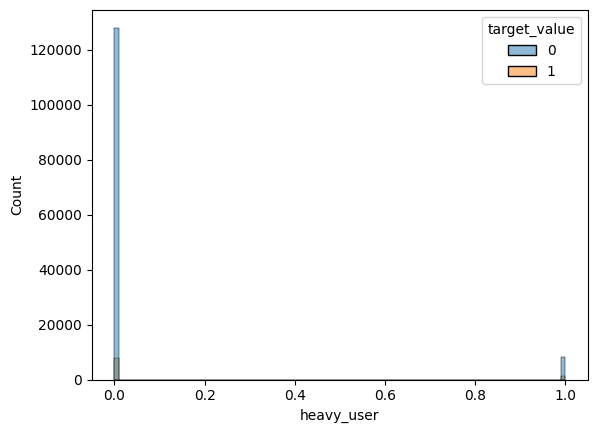

In [2312]:
sns.histplot(data=df, x='heavy_user', hue='target_value', bins=100)

In [2313]:
df

,front_id,decision_day,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,corp_credit_products,sum_deb_ul_90,sum_deb_ul_30,...,balance_rur_amt_30_min_flag,decision_day_flag,decision_weekend,rate_spread,rate_ratio,is_promo_rate,loan_to_od_max,od_range,weighted_spread,heavy_user
0,127345,2024-02-01,1.339991,-1.847954,-1.586546,1.774424,-0.400695,NaN,NaN,NaN,...,0,0,0,2.175119,-4.428370,0,-0.844596,0.261408,2.914639,0
1,127209,2024-02-01,-2.808489,-3.155914,-2.618329,1.774424,-0.400695,0.842771,NaN,NaN,...,0,0,0,2.175119,-4.428370,0,1.072626,0.537585,-6.108797,0
2,272776,2024-02-01,2.185431,3.167063,2.369547,-0.709770,-0.400695,0.000000,0.834373,4.897257,...,0,0,0,-0.309075,1.771348,0,0.922299,-0.797516,-0.675462,0
3,127210,2024-02-01,-1.468500,-2.595950,-2.176602,1.774424,-0.400695,NaN,NaN,NaN,...,0,0,0,2.175119,-4.428370,0,0.674676,0.419348,-3.194161,0
4,164500,2024-02-01,0.845440,4.559196,3.467730,-2.484194,-0.400695,0.000000,-0.518122,-3.435251,...,0,0,0,-2.083499,6.199718,0,0.243802,-1.091466,-1.761473,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145236,258918,2025-06-05,1.339991,2.480726,1.828130,3.903733,1.602779,0.000000,0.893285,5.247350,...,0,0,0,2.300954,2.435603,0,0.732984,-0.652595,3.083257,0
145237,176413,2025-06-05,0.845440,3.639458,3.605443,1.596982,1.602779,1.229059,0.576790,2.776671,...,0,0,0,-0.005797,0.996383,0,0.234490,-0.034015,-0.004901,0
145238,258920,2025-06-05,1.690880,3.960429,2.995393,3.903733,1.602779,1.234158,0.691625,4.440577,...,0,0,0,2.300954,2.435603,0,0.564494,-0.965036,3.890638,0
145239,174837,2025-06-05,0.845440,-2.742346,-2.292086,2.661636,1.602779,1.541025,0.109289,0.918909,...,0,0,0,1.058857,1.660639,0,-0.368852,0.450260,0.895200,0


In [2314]:
# poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
# df['app_term_mean_360']=df['app_term_mean_360'].fillna(df['app_term_mean_360'].median())
# poly_array = poly.fit_transform(df[['app_term_mean_360']])
# poly_df = pd.DataFrame(poly_array, columns=poly.get_feature_names_out())
# df = pd.concat([df, poly_df], axis=1)
# f=poly.get_feature_names_out()
# f

In [2315]:
df=pd.read_csv('train_apps.csv',sep=',')
df_feature=df.drop(columns=['target_value'],axis=1)
df_feature['cnt_deb_ul_ip_90'] = df_feature['cnt_deb_ul_ip_90'].fillna(df_feature['cnt_deb_ul_ip_90'].median())
df_feature['cnt_cred_loan_90_flag']=df_feature['cnt_cred_loan_90'].isna().astype(int)
df_feature['cnt_cred_loan_90'] = df_feature['cnt_cred_loan_90'].fillna(df_feature['cnt_cred_loan_90'].median())
df_feature['fl_hdb_bki_total_active_products'] = df_feature['fl_hdb_bki_total_active_products'].fillna(df_feature['fl_hdb_bki_total_active_products'].median())
df_feature['balance_rur_amt_30_min_flag']=df_feature['balance_rur_amt_30_min'].isna().astype(int)
df_feature['balance_rur_amt_30_min']=df_feature['balance_rur_amt_30_min'].fillna(0)

In [2316]:
df_feature['offered_rate'] = df_feature['offered_rate'].mask(df_feature['offered_rate'] < -50,-9999)
df_feature['offered_rate'] = df_feature['offered_rate'].mask(df_feature['offered_rate'] > 50,9999)

In [2317]:
df_feature['decision_day'] = pd.to_datetime(df_feature['decision_day'],errors='coerce')
df_feature['decision_day_flag'] = (df_feature['decision_day'].dt.day >= 25).astype(int)
df_feature['decision_weekend'] = (df_feature['decision_day'].dt.dayofweek >= 5).astype(int)
df_feature['count_all_corp_dashboard_events'] = df_feature['count_all_corp_dashboard_events'].fillna(0)
df_feature['rate_spread'] = df_feature['offered_rate'] - df_feature['cb_rate']
df_feature['rate_ratio'] = df_feature['offered_rate'] / df_feature['cb_rate']
df_feature['is_promo_rate'] = (df_feature['rate_spread'] < df_feature['rate_spread'].quantile(0.1)).astype(int)
df_feature['loan_to_od_max'] = df_feature['loan_amount_last'] / df_feature['overdraft_limit_max']
df_feature['loan_to_od_max_flag']=df_feature['loan_to_od_max'].isna().astype(int)
df_feature['loan_to_od_max'] = (df_feature['loan_to_od_max'].replace([np.inf, -np.inf], [9999, -9999]).fillna(0))
df_feature['od_range'] = df_feature['overdraft_limit_max'] - df_feature['overdraft_limit_min']
df_feature['weighted_spread'] = df_feature['rate_spread'] * df_feature['loan_amount_last']
df_feature['heavy_user'] = (df['p75_time_spent_minutes'] > df['p75_time_spent_minutes'].quantile(0.9)).astype(int)
poly = PolynomialFeatures(degree=2,include_bias=False)
df_feature['app_term_mean_360']=df_feature['app_term_mean_360'].fillna(df_feature['app_term_mean_360'].median())
poly_array = poly.fit_transform(df_feature[['app_term_mean_360']])
poly_df = pd.DataFrame(poly_array, columns=poly.get_feature_names_out())
df_feature['fl_adminarea_flag']=df_feature['fl_adminarea'].isna().astype(int)
df_feature['db_group_last_flag']=df_feature['db_group_last'].isna().astype(int)
df_feature['db_group_last']=df_feature['db_group_last'].fillna('Unknown')
df_feature['fl_adminarea']=df_feature['fl_adminarea'].fillna('Unknown')

In [2318]:
f=poly.get_feature_names_out()
df_feature['heavy_user'].describe()
poly_list=list(poly.get_feature_names_out())
poly_list

['app_term_mean_360', 'app_term_mean_360^2']

In [2319]:

df_feature=df_feature.drop(columns=['front_id','decision_day',
                                    'corp_credit_products','sum_deb_ul_90',
                                    'sum_deb_ul_30','cnt_deb_loan_90',
                                    'sum_deb_ul_90','cnt_deb_ul_ip_30',
                                    'loan_rev_max_start_non_fin','loan_rev_min_start_fin',
                                    'overdraft_app_term_max_360','days_from_authperson_registration',
                                    'corp_list',
                                    'p75_time_spent_minutes','app_term_mean_360','sum_deb_investment_90'],axis=1)

In [2320]:
df_feature = pd.concat([df_feature, poly_df], axis=1)

In [2321]:
df_feature

,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,cnt_deb_ul_ip_90,balance_rur_amt_30_min,cnt_cred_loan_90,fl_hdb_bki_total_active_products,count_all_corp_dashboard_events,...,is_promo_rate,loan_to_od_max,loan_to_od_max_flag,od_range,weighted_spread,heavy_user,fl_adminarea_flag,db_group_last_flag,app_term_mean_360,app_term_mean_360^2
0,1.339991,-1.847954,-1.586546,1.774424,-0.400695,0.147288,-5.561599,0.000000,0.000000,0.000000,...,0,-0.844596,0,0.261408,2.914639,0,1,0,1.767094,3.122620
1,-2.808489,-3.155914,-2.618329,1.774424,-0.400695,-4.466656,1.466815,0.000000,0.000000,-3.400318,...,0,1.072626,0,0.537585,-6.108797,0,1,0,-0.504888,0.254912
2,2.185431,3.167063,2.369547,-0.709770,-0.400695,5.291707,4.041974,0.000000,0.000000,3.015012,...,0,0.922299,0,-0.797516,-0.675462,0,1,1,0.000000,0.000000
3,-1.468500,-2.595950,-2.176602,1.774424,-0.400695,0.147288,-3.322507,0.000000,0.000000,0.000000,...,0,0.674676,0,0.419348,-3.194161,0,1,1,0.000000,0.000000
4,0.845440,4.559196,3.467730,-2.484194,-0.400695,-1.373655,4.324315,6.729738,0.000000,1.506380,...,0,0.243802,0,-1.091466,-1.761473,0,1,1,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145236,1.339991,2.480726,1.828130,3.903733,1.602779,2.599715,-5.527199,0.000000,1.302069,1.589065,...,0,0.732984,0,-0.652595,3.083257,0,0,0,0.000000,0.000000
145237,0.845440,3.639458,3.605443,1.596982,1.602779,-1.037194,3.052725,0.000000,-4.700790,0.665258,...,0,0.234490,0,-0.034015,-0.004901,0,0,0,0.000000,0.000000
145238,1.690880,3.960429,2.995393,3.903733,1.602779,2.863267,-5.561599,8.491984,-1.351879,2.272156,...,0,0.564494,0,-0.965036,3.890638,0,0,0,0.000000,0.000000
145239,0.845440,-2.742346,-2.292086,2.661636,1.602779,0.238218,-5.561599,16.983968,1.674455,-0.305594,...,0,-0.368852,0,0.450260,0.895200,0,0,0,-1.678739,2.818165


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
param_grid = {
    'model__max_iter': randint(100, 500),         
    'model__learning_rate': [0.02, 0.03, 0.05],
    'model__max_depth': [3, 4, 5],
    'model__min_samples_leaf': randint(10, 60),
    'model__l2_regularization': [0.0, 0.5, 1.0, 2.0],
    'model__max_leaf_nodes': [None, 31, 63, 127],  
}
num_features = [
    'loan_amount_last','overdraft_limit_min',
    'overdraft_limit_max','offered_rate',
    'cb_rate','cnt_deb_ul_ip_90',
    'cnt_cred_loan_90','fl_hdb_bki_total_active_products','count_all_corp_dashboard_events',
    'loan_to_od_max','weighted_spread','app_term_mean_360'
]

cat_features = [
    'fl_adminarea','db_group_last'
]


X = df_feature[num_features +cat_features]

y = df['target_value']

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    
])
pipe = Pipeline([
    ('prep', preprocess),
    ('model', HistGradientBoostingClassifier(
    learning_rate=0.03,
    max_iter=500,
    max_depth=5,
    min_samples_leaf=20,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=42,
    verbose=2
))
])
grid = RandomizedSearchCV(
    pipe,
    param_distributions=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=3,
    verbose=2,
    n_iter=30,
    random_state=42,    
    error_score='raise'
)

rus = RandomUnderSampler(random_state=42)
X_res_rus, y_res_rus = rus.fit_resample(X, y)
grid.fit(X_res_rus,y_res_rus)
best_model = grid.best_estimator_
y_pred = best_model.predict_proba(X_res_rus)[:, 1]
roc_auc_score(y_res_rus,y_pred)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Binning 0.013 GB of training data: 0.061 s
Binning 0.002 GB of validation data: 0.004 s
Fitting gradient boosted rounds:
[1/352] 1 tree, 16 leaves, max depth = 4, train loss: 0.68758, val loss: 0.68746, in 0.006s
[2/352] 1 tree, 16 leaves, max depth = 4, train loss: 0.68224, val loss: 0.68208, in 0.010s
[3/352] 1 tree, 16 leaves, max depth = 4, train loss: 0.67713, val loss: 0.67718, in 0.010s
[4/352] 1 tree, 16 leaves, max depth = 4, train loss: 0.67238, val loss: 0.67242, in 0.009s
[5/352] 1 tree, 16 leaves, max depth = 4, train loss: 0.66777, val loss: 0.66793, in 0.008s
[6/352] 1 tree, 16 leaves, max depth = 4, train loss: 0.66345, val loss: 0.66354, in 0.008s
[7/352] 1 tree, 16 leaves, max depth = 4, train loss: 0.65937, val loss: 0.65939, in 0.007s
[8/352] 1 tree, 16 leaves, max depth = 4, train loss: 0.65530, val loss: 0.65559, in 0.009s
[9/352] 1 tree, 16 leaves, max depth = 4, train loss: 0.65158, val loss: 0.65172,

0.8319836078738516

In [ ]:
from sklearn.inspection import permutation_importance
result = permutation_importance(
    best_model, X_res_rus, y_res_rus,
    n_repeats=5,
    random_state=42,
    scoring='roc_auc'
)

importances = result.importances_mean
feature_names = X_res_rus.columns  

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print("Топ-20 важных признаков:")
print(feat_imp.head(30))



Топ-20 важных признаков:
loan_amount_last                    0.051909
cnt_cred_loan_90                    0.046449
cb_rate                             0.030163
count_all_corp_dashboard_events     0.026734
db_group_last                       0.020394
overdraft_limit_min                 0.011757
overdraft_limit_max                 0.011682
offered_rate                        0.011380
cnt_deb_ul_ip_90                    0.010212
app_term_mean_360                   0.008945
loan_to_od_max                      0.008358
fl_adminarea                        0.005229
fl_hdb_bki_total_active_products    0.003974
weighted_spread                     0.002352
dtype: float64


In [2242]:
print(feat_imp.head(40))

loan_amount_last                    0.051624
cb_rate                             0.032069
cnt_cred_loan_90                    0.028342
count_all_corp_dashboard_events     0.028214
db_group_last                       0.019192
offered_rate                        0.012310
overdraft_limit_max                 0.012092
overdraft_limit_min                 0.010587
balance_rur_amt_30_min              0.010427
cnt_deb_ul_ip_90                    0.008334
app_term_mean_360                   0.007916
loan_to_od_max                      0.006841
fl_adminarea                        0.004648
fl_hdb_bki_total_active_products    0.003753
weighted_spread                     0.002399
cnt_cred_loan_90_flag               0.001365
app_term_mean_360^2                 0.000757
od_range                            0.000728
is_promo_rate                       0.000243
balance_rur_amt_30_min_flag         0.000123
heavy_user                          0.000051
dtype: float64


In [2323]:
print("Лучшие параметры:", grid.best_params_)
print("Лучший средний ROC-AUC на кросс-валидации:", grid.best_score_)
del df_feature

Лучшие параметры: {'model__l2_regularization': 0.0, 'model__learning_rate': 0.03, 'model__max_depth': 4, 'model__max_iter': 352, 'model__max_leaf_nodes': 127, 'model__min_samples_leaf': 34}
Лучший средний ROC-AUC на кросс-валидации: 0.8053277182016781


In [2325]:
df_feature=pd.read_csv('test_apps.csv',sep=',')
idx=df_feature['front_id']
df_feature['cnt_deb_ul_ip_90'] = df_feature['cnt_deb_ul_ip_90'].fillna(df_feature['cnt_deb_ul_ip_90'].median())
df_feature['cnt_cred_loan_90_flag']=df_feature['cnt_cred_loan_90'].isna().astype(int)
df_feature['cnt_cred_loan_90'] = df_feature['cnt_cred_loan_90'].fillna(df_feature['cnt_cred_loan_90'].median())
df_feature['fl_hdb_bki_total_active_products'] = df_feature['fl_hdb_bki_total_active_products'].fillna(df_feature['fl_hdb_bki_total_active_products'].median())
df_feature['balance_rur_amt_30_min_flag']=df_feature['balance_rur_amt_30_min'].isna().astype(int)
df_feature['balance_rur_amt_30_min']=df_feature['balance_rur_amt_30_min'].fillna(0)
df_feature['offered_rate'] = df_feature['offered_rate'].mask(df_feature['offered_rate'] < -50,-9999)
df_feature['offered_rate'] = df_feature['offered_rate'].mask(df_feature['offered_rate'] > 50,9999)
df_feature['decision_day'] = pd.to_datetime(df_feature['decision_day'],errors='coerce')
df_feature['decision_day_flag'] = (df_feature['decision_day'].dt.day >= 25).astype(int)
df_feature['decision_weekend'] = (df_feature['decision_day'].dt.dayofweek >= 5).astype(int)
df_feature['count_all_corp_dashboard_events'] = df_feature['count_all_corp_dashboard_events'].fillna(0)
df_feature['rate_spread'] = df_feature['offered_rate'] - df_feature['cb_rate']
df_feature['rate_ratio'] = df_feature['offered_rate'] / df_feature['cb_rate']
df_feature['rate_ratio'] = (df_feature['rate_ratio'].replace([np.inf, -np.inf], [9999, -9999]).fillna(0))
df_feature['is_promo_rate'] = (df_feature['rate_spread'] < df_feature['rate_spread'].quantile(0.1)).astype(int)
df_feature['loan_to_od_max'] = df_feature['loan_amount_last'] / df_feature['overdraft_limit_max']
df_feature['loan_to_od_max_flag']=df_feature['loan_to_od_max'].isna().astype(int)
df_feature['loan_to_od_max'] = (df_feature['loan_to_od_max'].replace([np.inf, -np.inf], [9999, -9999]).fillna(0))
df_feature['od_range'] = df_feature['overdraft_limit_max'] - df_feature['overdraft_limit_min']
df_feature['weighted_spread'] = df_feature['rate_spread'] * df_feature['loan_amount_last']
df_feature['heavy_user'] = (df_feature['p75_time_spent_minutes'] > df_feature['p75_time_spent_minutes'].quantile(0.9)).astype(int)
poly = PolynomialFeatures(degree=2,include_bias=False)
df_feature['app_term_mean_360']=df_feature['app_term_mean_360'].fillna(df_feature['app_term_mean_360'].median())
poly_array = poly.fit_transform(df_feature[['app_term_mean_360']])
poly_df = pd.DataFrame(poly_array, columns=poly.get_feature_names_out())
f=poly.get_feature_names_out()
df_feature['heavy_user'].describe()
poly_list=list(poly.get_feature_names_out())
df_feature=df_feature.drop(columns=['front_id','decision_day',
                                    'corp_credit_products','sum_deb_ul_90',
                                    'sum_deb_ul_30','cnt_deb_loan_90',
                                    'sum_deb_ul_90','cnt_deb_ul_ip_30',
                                    'loan_rev_max_start_non_fin','loan_rev_min_start_fin',
                                    'overdraft_app_term_max_360','days_from_authperson_registration',
                                    'corp_list',
                                    'p75_time_spent_minutes','app_term_mean_360','sum_deb_investment_90'],axis=1)

df_feature = pd.concat([df_feature, poly_df], axis=1)


In [ ]:
print("inf в rate_ratio:", np.isinf(df_feature['rate_ratio']).sum())  
print("NaN в rate_ratio:", df_feature['rate_ratio'].isna().sum())    

inf в rate_ratio: 0
NaN в rate_ratio: 0


In [2327]:
num_features = [
    'loan_amount_last','overdraft_limit_min',
    'overdraft_limit_max','offered_rate',
    'cb_rate','cnt_deb_ul_ip_90',
    'cnt_cred_loan_90','fl_hdb_bki_total_active_products','count_all_corp_dashboard_events',
    'loan_to_od_max','weighted_spread','app_term_mean_360'
]

cat_features = [
    'fl_adminarea','db_group_last'
]


X = df_feature[num_features +cat_features]




In [2328]:
df_out = pd.DataFrame()
df_out['front_id'] = idx
df_out['target_value'] = best_model.predict_proba(X)[:, 1]
df_out.to_csv('submission.csv', index=False)